# Загрузка данных и библиотек
---

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns
import copy

RANDOM_STATE = 0xFACED

In [2]:
train_raw = pd.read_csv('./data/train.csv')
test_raw = pd.read_csv('./data/test.csv')

train = train_raw.copy()
test = test_raw.copy()

# EDA
---

In [3]:
train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


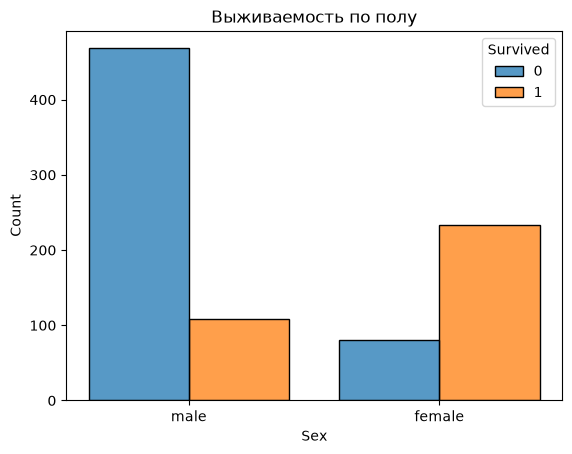

In [4]:
sns.histplot(data=train, x='Sex', hue='Survived', multiple='dodge', shrink=0.8)
plt.title('Выживаемость по полу')
plt.show()

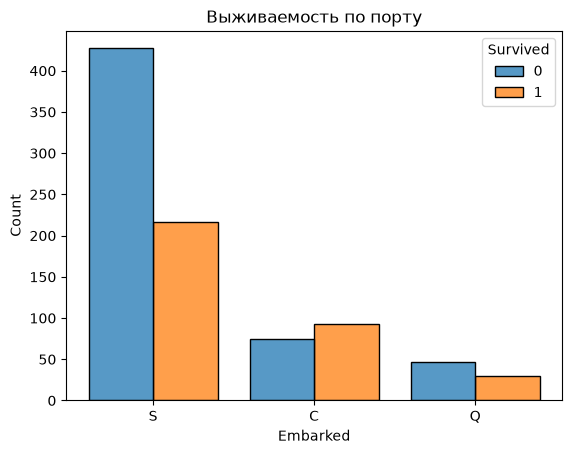

In [5]:
sns.histplot(data=train, x='Embarked', hue='Survived', multiple='dodge', shrink=0.8)
plt.title('Выживаемость по порту')
plt.show()

In [6]:
print(f"Пропуски в train по колонкам (из {train.shape[0]}):")
for col in train.columns:
    if train[col].isna().any():
        print(f"{col}: {train[col].isna().sum()}")

print(f"\nПропуски в test по колонкам (из {test.shape[0]}):")
for col in test.columns:
    if test[col].isna().any():
        print(f"{col}: {test[col].isna().sum()}")

Пропуски в train по колонкам (из 891):
Age: 177
Cabin: 687
Embarked: 2

Пропуски в test по колонкам (из 418):
Age: 86
Fare: 1
Cabin: 327


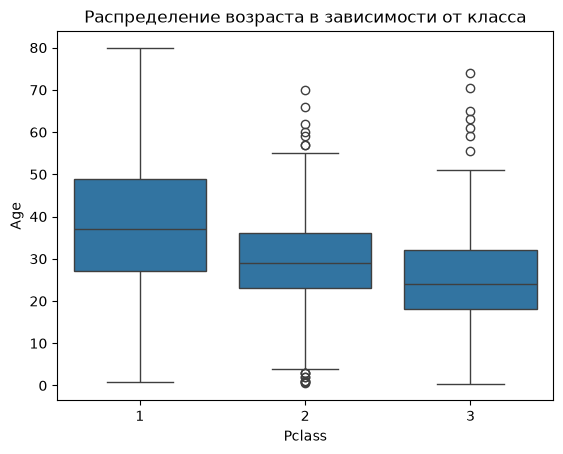

In [7]:
sns.boxplot(x='Pclass', y='Age', data=train)
plt.title('Распределение возраста в зависимости от класса')
plt.show()

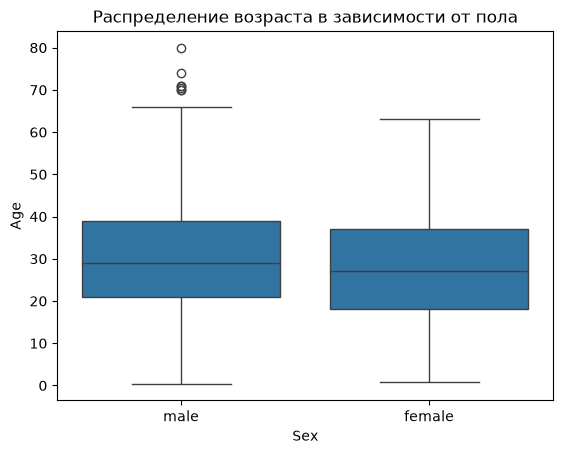

In [8]:
sns.boxplot(x='Sex', y='Age', data=train)
plt.title('Распределение возраста в зависимости от пола')
plt.show()

# Предобработка данных
---

Для удобства объединим `train` и `test` в один датасет `df`

In [9]:
df = pd.concat([train, test], sort=False).reset_index(drop=True)
train_mask = df['Survived'].notna()

Извлечем титул пассажира из колонки `Name`

In [10]:
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.')
print(df['Title'].value_counts())

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Ms            2
Major         2
Mlle          2
Don           1
Mme           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64


Объединим редкие титулы под названием `Other`, объединим женские титулы привычным образом

In [11]:
other_titles = ['Rev', 'Dr', 'Col', 'Major', 'Capt', 'Jonkheer', 'Don', 'Sir', 'Lady', 'Countess', 'Dona']
df['Title'] = df['Title'].replace(other_titles, 'Other')

df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

df['Title'].value_counts()

Title
Mr        757
Miss      264
Mrs       198
Master     61
Other      29
Name: count, dtype: int64

Доля выживаемости в зависимости от статуса

In [12]:
df[train_mask].groupby('Title')['Survived'].mean().sort_values(ascending=False)

Title
Mrs       0.793651
Miss      0.702703
Master    0.575000
Other     0.347826
Mr        0.156673
Name: Survived, dtype: float64

Средний возраст в зависимости от статуса

In [13]:
df[train_mask].groupby('Title')['Age'].mean().sort_values(ascending=False)

Title
Other     45.545455
Mrs       35.788991
Mr        32.368090
Miss      21.845638
Master     4.574167
Name: Age, dtype: float64

Заполним пропуски `Age` в зависимости от `Sex`, `Pclass`, `Title`

In [14]:
group_keys = ['Sex', 'Pclass', 'Title']
group_mean_age = df.loc[train_mask].groupby(group_keys)['Age'].mean()
age_from_train_groups = pd.Series(df.set_index(group_keys).index.map(group_mean_age), index=df.index)
train_median_age = df.loc[train_mask, 'Age'].median()

df['Age'] = df['Age'].fillna(age_from_train_groups).fillna(train_median_age)

Заполним пропуски `Embarked` на самый частый порт

In [15]:
df['Embarked'] = df['Embarked'].fillna(df.loc[train_mask]['Embarked'].mode()[0])

Заполним пропуски `Fare` в зависимости от `Pclass`, `Embarked`, `Title`, семейного положения

In [16]:
df[df['Fare'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,Mr


In [17]:
fare_median = df.loc[train_mask & (df['Pclass'] == 3) & (df['Embarked'] == 'S') & (df['Title'] == 'Mr') & (df['SibSp'] + df['Parch'] == 0), 'Fare'].median()
df.loc[df['Fare'].isna(), 'Fare'] = fare_median

Создадим бинарный признак `HasCabin` - известен ли номер кабинки пассажира

In [18]:
df['HasCabin'] = df['Cabin'].notna().astype(int)
df.drop(['Cabin'], axis=1, inplace=True)
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,HasCabin
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,1
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,1
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,0


In [19]:
display(pd.crosstab(df.loc[train_mask, 'HasCabin'], df.loc[train_mask, 'Survived']))
display(pd.crosstab(df.loc[train_mask, 'HasCabin'], df.loc[train_mask, 'Pclass']))

Survived,0.0,1.0
HasCabin,,
0,481,206
1,68,136


Pclass,1,2,3
HasCabin,,,
0,40,168,479
1,176,16,12


Видно, что большая часть людей, чья кабинка неизвестна - погибли. Также видно, что чем лучше класс, тем больше известных кабинок

Сделаем признак `Sex` бинарным

In [20]:
df['Sex'] = (df['Sex'] == 'female').astype(int)

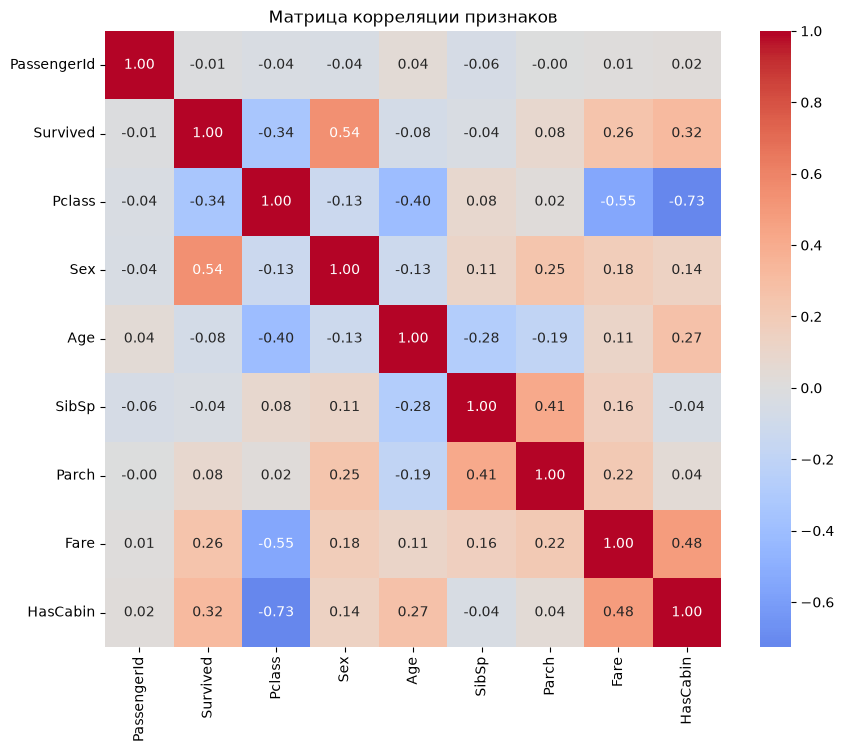

In [21]:
corr_matrix = df[train_mask].select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляции признаков')
plt.show()

Удаляем ненужные колонки

In [22]:
columns_drop = ['PassengerId', 'Ticket', 'Name']
df.drop(columns_drop, axis=1, inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin
0,0.0,3,0,22.0,1,0,7.2500,S,Mr,0
1,1.0,1,1,38.0,1,0,71.2833,C,Mrs,1
2,1.0,3,1,26.0,0,0,7.9250,S,Miss,0
3,1.0,1,1,35.0,1,0,53.1000,S,Mrs,1
4,0.0,3,0,35.0,0,0,8.0500,S,Mr,0


Сохраняем датасет с категориальными переменными для CatBoost, для остальных моделей - применяем One-Hot-Encoding

In [23]:
df_cat = df.copy()
cat_features = ['Embarked', 'Title']
df = pd.get_dummies(df, columns=cat_features)

Убираем лишние колонки после One-Hot-Encoding

In [24]:
columns_drop = ['Embarked_Q', 'Title_Other']
df.drop(columns_drop, axis=1, inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,Embarked_C,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,0.0,3,0,22.0,1,0,7.2500,0,False,True,False,False,True,False
1,1.0,1,1,38.0,1,0,71.2833,1,True,False,False,False,False,True
2,1.0,3,1,26.0,0,0,7.9250,0,False,True,False,True,False,False
3,1.0,1,1,35.0,1,0,53.1000,1,False,True,False,False,False,True
4,0.0,3,0,35.0,0,0,8.0500,0,False,True,False,False,True,False


In [25]:
train, test = df[train_mask], df[~train_mask]
train_cat, test_cat = df_cat[train_mask], df_cat[~train_mask]

X = train.drop('Survived', axis=1)
y = train['Survived']
X_cat = train_cat.drop('Survived', axis=1)
y_cat = train_cat['Survived']

# Classic ML
---

Создаем функцию для обучения моделей

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

def run_model(name, estimator, X, y, cv, needs_scaling=False, fit_params=None, stats=None):
    """Честная OOF-оценка + финальная модель на 100% данных. Работает одинаково для ЛЮБОЙ модели."""
    fit_params = fit_params or {}
    oof_proba = np.zeros(len(y))
    fold_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if needs_scaling:
            scaler = StandardScaler()
            X_tr, X_val = scaler.fit_transform(X_tr), scaler.transform(X_val)

        model = clone(estimator)
        model.fit(X_tr, y_tr, **fit_params)
        fold_proba = model.predict_proba(X_val)[:, 1]
        oof_proba[val_idx] = fold_proba

        fold_acc = accuracy_score(y_val, (fold_proba >= 0.5).astype(int))
        fold_scores.append(fold_acc)

    acc = accuracy_score(y, (oof_proba >= 0.5).astype(int))
    if stats is not None:
        stats[name] = acc
    print(f'{name}: OOF accuracy = {acc:.4f} | по фолдам: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')

    scaler_full = StandardScaler().fit(X) if needs_scaling else None
    X_full = scaler_full.transform(X) if scaler_full else X
    final_model = clone(estimator).fit(X_full, y, **fit_params)

    return {'oof_proba': oof_proba, 'model': final_model, 'scaler': scaler_full, 'fold_scores': fold_scores}

### Dummy Classifier - baseline

In [27]:
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X, y)
accuracy = dummy_model.score(X, y)
print(f"Точность наивного классификатора: {accuracy:.2f}")

Точность наивного классификатора: 0.62


### Logistic Regression

In [28]:
def get_tuned_logistic_regression(X, y, cv, verbose=True):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ])
    param_grid = [
        {
            'model__solver': ['lbfgs'],
            'model__C': np.logspace(-3, 2, 12),
        },
        {
            'model__solver': ['liblinear'],
            'model__l1_ratio': [0, 1],
            'model__C': np.logspace(-3, 2, 12),
        },
        {
            'model__solver': ['saga'],
            'model__l1_ratio': [0.2, 0.5, 0.8],
            'model__C': np.logspace(-3, 2, 12),
        }]

    search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    search.fit(X, y)
    if verbose:
        print('LogisticRegression:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_.named_steps['model']

lr_tuned = get_tuned_logistic_regression(X, y, cv)

LogisticRegression:
                   value
model__C         0.53367
model__l1_ratio      0.5
model__solver       saga


In [29]:
stats_stage1 = {}
results_stage1 = {}

results_stage1['lr'] = run_model('LogisticRegression', lr_tuned, X, y, cv, needs_scaling=True, stats=stats_stage1)
lr_model = results_stage1['lr']['model']

LogisticRegression: OOF accuracy = 0.8350 | по фолдам: 0.8350 ± 0.0170


### KNN

In [30]:
def get_tuned_knn(X, y, cv, verbose=True):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ])
    param_grid = [
        {'model__n_neighbors': np.arange(1, 50), 'model__weights': ['uniform', 'distance'], 'model__metric': ['euclidean', 'manhattan']},
        {'model__n_neighbors': np.arange(1, 50), 'model__weights': ['uniform', 'distance'], 'model__metric': ['minkowski'], 'model__p': [1, 2, 3]},
    ]

    search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    search.fit(X, y)
    if verbose:
        print('KNeighborsClassifier:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_.named_steps['model']

knn_tuned = get_tuned_knn(X, y, cv)

KNeighborsClassifier:
                        value
model__metric       manhattan
model__n_neighbors         10
model__weights        uniform


In [31]:
results_stage1['knn'] = run_model('KNeighborsClassifier', knn_tuned, X, y, cv, needs_scaling=True, stats=stats_stage1)
knn_model = results_stage1['knn']['model']

KNeighborsClassifier: OOF accuracy = 0.8215 | по фолдам: 0.8215 ± 0.0200


### Decision Tree

In [32]:
def get_tuned_decision_tree(X, y, cv, verbose=True):
    param_grid = {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [None, 2, 3, 4, 5, 7, 10, 12, 15], 
        'min_samples_split': np.arange(2, 30, 2),
        'min_samples_leaf': np.arange(1, 20, 2),
        'max_features': [None, 'sqrt', 'log2', 0.5, 0.7] 
    }

    search = RandomizedSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid, n_iter=300, cv=cv, scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X, y)
    if verbose:
        print('DecisionTreeClassifier:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

tree_tuned = get_tuned_decision_tree(X, y, cv)

DecisionTreeClassifier:
                      value
min_samples_split        26
min_samples_leaf          7
max_features            0.7
max_depth                 7
criterion          log_loss


In [33]:
results_stage1['tree'] = run_model('DecisionTreeClassifier', tree_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
tree_model = results_stage1['tree']['model']

DecisionTreeClassifier: OOF accuracy = 0.8227 | по фолдам: 0.8226 ± 0.0267


### Random Forest

In [34]:
def get_tuned_random_forest(X, y, cv, verbose=True):
    param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_samples': [0.5, 0.7, 0.9, None],
        'max_depth': [2, 3, 4, 5],
        'max_features': ['sqrt', 'log2', 0.4, 0.6],
        'min_samples_split': [2, 4, 5, 7, 10],
        'min_samples_leaf': [1, 2, 4, 5, 7, 10],
    }

    search = RandomizedSearchCV(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), param_grid, n_iter=100, cv=cv, scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X, y)
    if verbose:
        print('RandomForestClassifier:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

rf_tuned = get_tuned_random_forest(X, y, cv)

RandomForestClassifier:
                     value
min_samples_split        4
min_samples_leaf         2
max_samples            0.5
max_features           0.4
max_depth                5
criterion          entropy


In [35]:
results_stage1['rf'] = run_model('RandomForestClassifier', rf_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
rf_model = results_stage1['rf']['model']

RandomForestClassifier: OOF accuracy = 0.8350 | по фолдам: 0.8350 ± 0.0106


### CatBoost

In [36]:
def get_tuned_catboost(X, y, cv, cat_features, verbose=True):
    param_grid = {
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'depth': [3, 4, 5, 6, 8],                
        'l2_leaf_reg': [1, 3, 5, 10, 20],
        'random_strength': [0.0, 0.2, 0.5, 1.0],
        'bagging_temperature': [0.0, 0.4, 0.8, 1.0]
    }

    model = CatBoostClassifier(loss_function='Logloss', random_seed=RANDOM_STATE, iterations=300, logging_level='Silent', allow_writing_files=False, cat_features=cat_features)
    cv_splits = list(cv.split(X, y))
    search = model.randomized_search(
        param_grid, X=X, y=y, cv=cv_splits, n_iter=40,
        partition_random_seed=RANDOM_STATE, verbose=False, plot=False
    )
    if verbose:
        print('CatBoostClassifier:')
        print(pd.DataFrame.from_dict(search['params'], orient='index', columns=['value']), end='\n')
    return model

cb_tuned = get_tuned_catboost(X_cat, y_cat, cv,  cat_features=['Title', 'Embarked'])

CatBoostClassifier:
                     value
bagging_temperature   0.40
random_strength       0.50
depth                 8.00
learning_rate         0.05
l2_leaf_reg           3.00


In [37]:
best_params = cb_tuned.get_params()
best_params.pop('cat_features', None)
cb_template = CatBoostClassifier(**best_params)

results_stage1['cb'] = run_model('CatBoostClassifier', cb_template, X_cat, y_cat, cv, fit_params={'cat_features': ['Title', 'Embarked']}, needs_scaling=False, stats=stats_stage1)
cb_model = results_stage1['cb']['model']

CatBoostClassifier: OOF accuracy = 0.8260 | по фолдам: 0.8260 ± 0.0120


### LightGBM

In [38]:
def get_tuned_lightgbm(X, y, cv, verbose=True):
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'num_leaves': np.arange(5, 20, 3),
        'max_depth': [-1, 3, 5, 7],
        'min_child_samples': [10, 15, 20, 25, 30]
    }

    search = RandomizedSearchCV(LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1), param_grid, n_iter=200, scoring='accuracy', cv=cv, n_jobs=1, random_state=RANDOM_STATE)
    search.fit(X, y)
    if verbose:
        print('LGBMClassifier:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

lgbm_tuned = get_tuned_lightgbm(X, y, cv)

LGBMClassifier:
                   value
num_leaves           8.0
n_estimators       100.0
min_child_samples   30.0
max_depth            5.0
learning_rate        0.1


In [39]:
results_stage1['lgbm'] = run_model('LGBMClassifier', lgbm_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
lgbm_model = results_stage1['lgbm']['model']

LGBMClassifier: OOF accuracy = 0.8440 | по фолдам: 0.8440 ± 0.0097


### XGBoost

In [40]:
def get_tuned_xgboost(X, y, cv, verbose=True):
    param_grid = {
        'n_estimators': np.arange(50, 301, 50),
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'max_depth': [3, 4, 5, 6, 7],
        'min_child_weight': [1, 2, 4, 6, 8, 10],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
    }

    search = RandomizedSearchCV(XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1), param_grid, n_iter=100, scoring='accuracy', cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
    search.fit(X, y)
    if verbose:
        print('XGBClassifier:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

xgb_tuned = get_tuned_xgboost(X, y, cv)

XGBClassifier:
                  value
subsample           0.9
n_estimators      100.0
min_child_weight    6.0
max_depth           7.0
learning_rate       0.1
colsample_bytree    0.8


In [41]:
results_stage1['xgb'] = run_model('XGBClassifier', xgb_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
xgb_model = results_stage1['xgb']['model']

XGBClassifier: OOF accuracy = 0.8429 | по фолдам: 0.8429 ± 0.0147


# Итоги по Classic ML

In [42]:
def print_sorted_stats(stats):
    stats = dict(
        sorted(stats.items(), key=lambda x: x[1], reverse=True)
    )

    print('┌' + '─' * 24 + '┬' + '─' * 13 + '┐')
    print(f"│ {'Classifier':<22} │ {'CV accuracy':<10} │")
    print('├' + '─' * 24 + '┼' + '─' * 13 + '┤')

    for model_name, accuracy in stats.items():
        print(f"│ {model_name:<22} │ {accuracy:<11.4f} │")

    print('└' + '─' * 24 + '┴' + '─' * 13 + '┘')

print_sorted_stats(stats_stage1)

┌────────────────────────┬─────────────┐
│ Classifier             │ CV accuracy │
├────────────────────────┼─────────────┤
│ LGBMClassifier         │ 0.8440      │
│ XGBClassifier          │ 0.8429      │
│ LogisticRegression     │ 0.8350      │
│ RandomForestClassifier │ 0.8350      │
│ CatBoostClassifier     │ 0.8260      │
│ DecisionTreeClassifier │ 0.8227      │
│ KNeighborsClassifier   │ 0.8215      │
└────────────────────────┴─────────────┘


# Deep Learning
---

In [43]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [44]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True, stratify=y)
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_val_scaled   = scaler_nn.transform(X_val)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

### Первая версия

In [45]:
class NN1(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 16)
        self.layer_2 = nn.Linear(16, 16)
        self.layer_3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        x = self.relu(x)
        x = self.layer_3(x)
        return x

input_dim = X_train_tensor.shape[1]
nn1_model = NN1(input_dim).to(device)

In [46]:
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(nn1_model.parameters(), lr=0.001)

In [47]:
EPOCHS = 100
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(EPOCHS):
    nn1_model.train()
    train_loss = 0
    true_answer = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn1_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(y_pred)
        preds_classes = (probs >= 0.5).float()
        true_answer += (preds_classes == y_batch).sum().item()

    train_losses.append(train_loss / len(train_loader))
    train_acc.append(true_answer / len(y_train_tensor))

    nn1_model.eval()
    with torch.no_grad():
        y_val_pred = nn1_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()

        val_probs = torch.sigmoid(y_val_pred)
        val_preds_classes = (val_probs >= 0.5).float()
        val_true_answer = (val_preds_classes == y_val_target).sum().item()

    val_losses.append(val_loss)
    val_acc.append(val_true_answer / len(y_val_tensor))
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_acc: {train_acc[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_acc: {val_acc[-1]:.4f}')

[EPOCH  10/100] train_loss: 0.5664, train_acc: 0.8076 | val_loss: 0.5351, val_acc: 0.8101
[EPOCH  20/100] train_loss: 0.5129, train_acc: 0.8272 | val_loss: 0.5059, val_acc: 0.8324
[EPOCH  30/100] train_loss: 0.5078, train_acc: 0.8357 | val_loss: 0.4985, val_acc: 0.8268
[EPOCH  40/100] train_loss: 0.4975, train_acc: 0.8427 | val_loss: 0.4940, val_acc: 0.8212
[EPOCH  50/100] train_loss: 0.4969, train_acc: 0.8399 | val_loss: 0.4995, val_acc: 0.8212
[EPOCH  60/100] train_loss: 0.4814, train_acc: 0.8413 | val_loss: 0.4934, val_acc: 0.8268
[EPOCH  70/100] train_loss: 0.4876, train_acc: 0.8441 | val_loss: 0.4957, val_acc: 0.8156
[EPOCH  80/100] train_loss: 0.4715, train_acc: 0.8469 | val_loss: 0.4955, val_acc: 0.8212
[EPOCH  90/100] train_loss: 0.4869, train_acc: 0.8469 | val_loss: 0.4968, val_acc: 0.8156
[EPOCH 100/100] train_loss: 0.4581, train_acc: 0.8511 | val_loss: 0.4951, val_acc: 0.8156


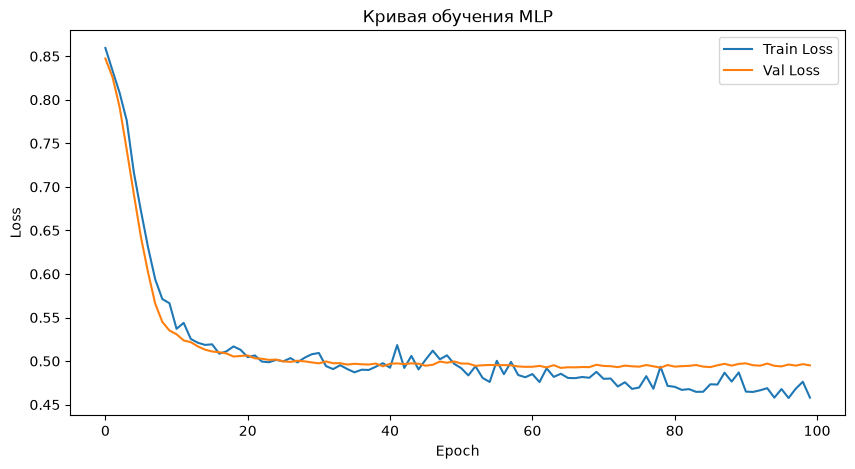

In [48]:
def plot_nn_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Кривая обучения MLP')
    plt.show()

plot_nn_losses(train_losses, val_losses)

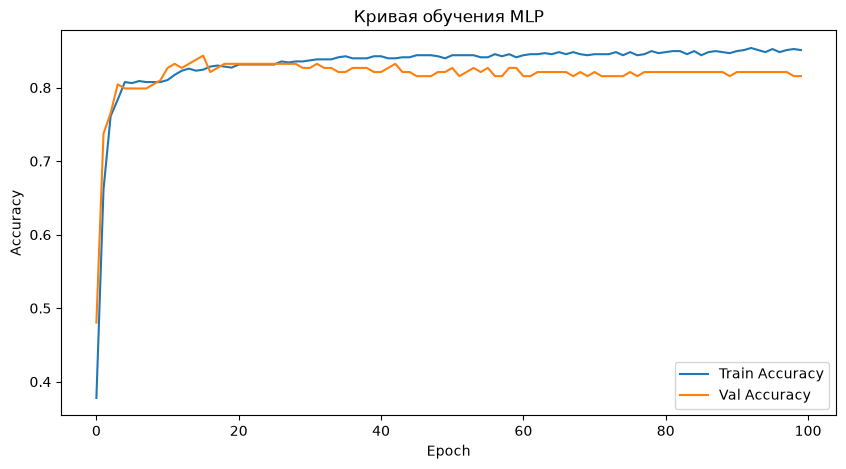

In [49]:
def plot_nn_acc(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Кривая обучения MLP')
    plt.show()

plot_nn_acc(train_acc, val_acc)

In [50]:
stats_stage1['NN1'] = sum(val_acc) / len(val_acc)

### Добавляем BatchNorm, DropOut, Early Stopping

In [51]:
class NN2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer_2(x))))
        return self.layer_3(x)

input_dim = X_train_tensor.shape[1]
nn2_model = NN2(input_dim).to(device)

In [52]:
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(nn2_model.parameters(), lr=0.001, weight_decay=1e-4)

In [53]:
EPOCHS = 150
train_losses, val_losses = [], []
train_acc, val_acc = [], []

best_val_loss = float('inf')
best_model_weights = None

for epoch in range(EPOCHS):
    nn2_model.train()
    train_loss = 0
    true_answer = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn2_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        probs = torch.sigmoid(y_pred)
        preds_classes = (probs >= 0.5).float()
        true_answer += (preds_classes == y_batch).sum().item()
    
    train_losses.append(train_loss / len(train_loader))
    train_acc.append(true_answer / len(y_train_tensor))

    nn2_model.eval()
    with torch.no_grad():
        y_val_pred = nn2_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()

        val_probs = torch.sigmoid(y_val_pred)
        val_preds_classes = (val_probs >= 0.5).float()
        val_true_answer = (val_preds_classes == y_val_target).sum().item()

    val_losses.append(val_loss)
    val_acc.append(val_true_answer / len(y_val_tensor))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(nn2_model.state_dict())
    
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_acc: {train_acc[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_acc: {val_acc[-1]:.4f}')
        

[EPOCH  10/150] train_loss: 0.5712, train_acc: 0.8174 | val_loss: 0.5285, val_acc: 0.8324
[EPOCH  20/150] train_loss: 0.5735, train_acc: 0.8118 | val_loss: 0.5078, val_acc: 0.8380
[EPOCH  30/150] train_loss: 0.5373, train_acc: 0.8174 | val_loss: 0.5003, val_acc: 0.8324
[EPOCH  40/150] train_loss: 0.5448, train_acc: 0.8287 | val_loss: 0.4938, val_acc: 0.8324
[EPOCH  50/150] train_loss: 0.5474, train_acc: 0.8202 | val_loss: 0.4934, val_acc: 0.8268
[EPOCH  60/150] train_loss: 0.5584, train_acc: 0.8301 | val_loss: 0.4864, val_acc: 0.8380
[EPOCH  70/150] train_loss: 0.5667, train_acc: 0.8287 | val_loss: 0.4843, val_acc: 0.8324
[EPOCH  80/150] train_loss: 0.5066, train_acc: 0.8385 | val_loss: 0.4837, val_acc: 0.8212
[EPOCH  90/150] train_loss: 0.5265, train_acc: 0.8230 | val_loss: 0.4833, val_acc: 0.8436
[EPOCH 100/150] train_loss: 0.5294, train_acc: 0.8258 | val_loss: 0.4807, val_acc: 0.8380
[EPOCH 110/150] train_loss: 0.5044, train_acc: 0.8455 | val_loss: 0.4884, val_acc: 0.8324
[EPOCH 120

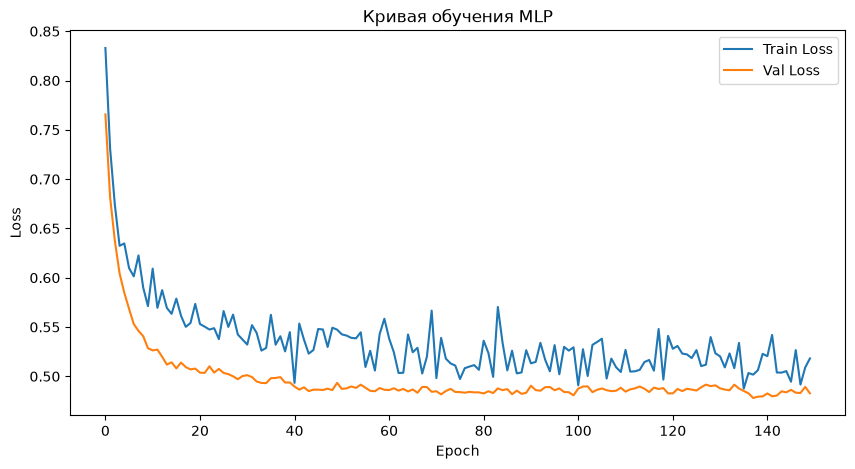

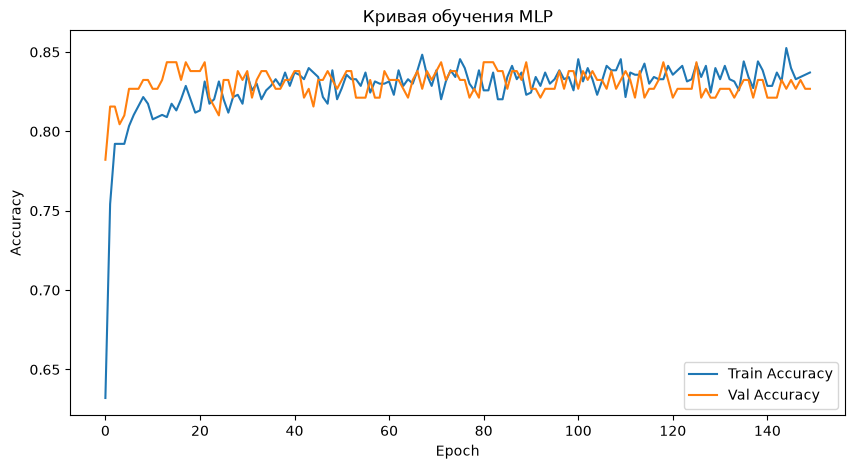

In [54]:
plot_nn_losses(train_losses, val_losses)
plot_nn_acc(train_acc, val_acc)

In [55]:
stats_stage1['NN2'] = sum(val_acc) / len(val_acc)

### Добавляем Scheduler, меняем функции активации

In [56]:
class NN3(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.silu1 = nn.SiLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.silu2 = nn.SiLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.silu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.silu2(self.bn2(self.layer_2(x))))
        return self.layer_3(x)

input_dim = X_train_tensor.shape[1]
nn3_model = NN3(input_dim).to(device)

In [57]:
class_counts = y_train.value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(nn3_model.parameters(), lr=0.005, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.1)

In [58]:
def get_fitted_nn(nn_model, train_loader, X_val, y_val, scheduler, EPOCHS, early_stopping=True, patience=10, min_delta=1e-4, verbose=True):
    train_losses, val_losses = [], []
    train_acc, val_acc = [], []
    if early_stopping:
        best_val_loss = float('inf')
        best_model_weights = None

    patience_counter = 0
    for epoch in range(EPOCHS):
        nn_model.train()
        train_loss = 0
        true_answer = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = nn_model(X_batch)
            y_batch = y_batch.view(-1, 1)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            probs = torch.sigmoid(y_pred)
            preds_classes = (probs >= 0.5).float()
            true_answer += (preds_classes == y_batch).sum().item()
        
        train_losses.append(train_loss / len(train_loader))
        train_acc.append(true_answer / len(y_train_tensor))

        nn_model.eval()
        with torch.no_grad():
            y_val_pred = nn_model(X_val)
            y_val_target = y_val.view(-1, 1)
            val_loss = criterion(y_val_pred, y_val_target).item()

            val_probs = torch.sigmoid(y_val_pred)
            val_preds_classes = (val_probs >= 0.5).float()
            val_true_answer = (val_preds_classes == y_val_target).sum().item()

        val_losses.append(val_loss)
        val_acc.append(val_true_answer / len(y_val))

        if early_stopping:
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_val_acc = val_acc[-1]
                best_model_weights = copy.deepcopy(nn_model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if verbose:
                        print(f'EARLY STOPPING at epoch {epoch+1}')
                    break
        scheduler.step(val_loss)
        if verbose and (epoch + 1) % 10 == 0:
            print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_loss: {train_losses[-1]:.4f}, train_acc: {train_acc[-1]:.4f} | val_loss: {val_losses[-1]:.4f}, val_acc: {val_acc[-1]:.4f}')
    if early_stopping:
        nn_model.load_state_dict(best_model_weights)
        nn_model.eval()
    return nn_model, (train_losses, val_losses, train_acc, val_acc)


nn3_model, nn_stats = get_fitted_nn(nn3_model, train_loader, X_val_tensor, y_val_tensor, scheduler, EPOCHS=200)
train_losses, val_losses, train_acc, val_acc = nn_stats

[EPOCH  10/200] train_loss: 0.5463, train_acc: 0.8258 | val_loss: 0.4974, val_acc: 0.8436
[EPOCH  20/200] train_loss: 0.5464, train_acc: 0.8329 | val_loss: 0.4912, val_acc: 0.8380
[EPOCH  30/200] train_loss: 0.5599, train_acc: 0.8315 | val_loss: 0.4918, val_acc: 0.8547
[EPOCH  40/200] train_loss: 0.5193, train_acc: 0.8329 | val_loss: 0.4802, val_acc: 0.8436
EARLY STOPPING at epoch 50


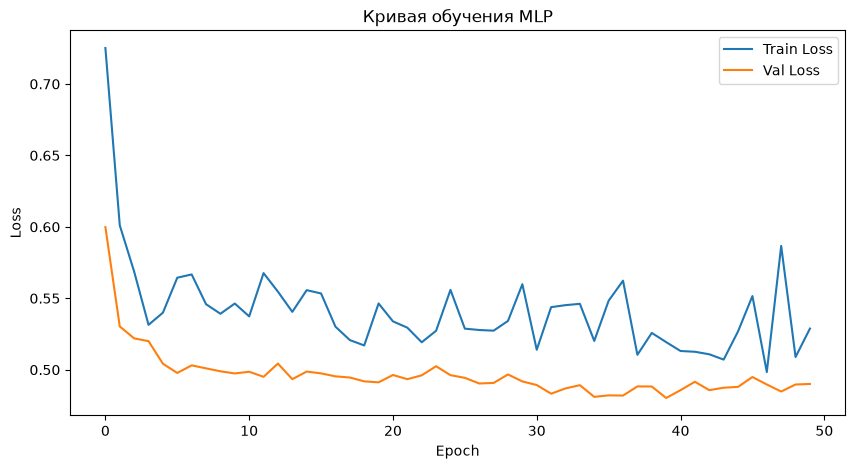

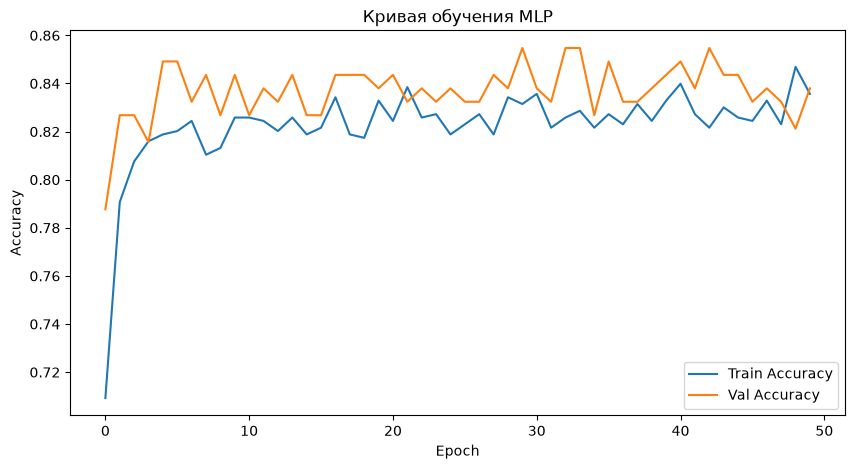

In [59]:
plot_nn_losses(train_losses, val_losses)
plot_nn_acc(train_acc, val_acc)

In [ ]:
class TorchNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_dim=32, dropout1=0.3, dropout2=0.2,
                 lr=0.005, weight_decay=1e-4, epochs=150, batch_size=32,
                 val_split=0.2, patience=10, min_delta=1e-4, device=None):
        self.hidden_dim = hidden_dim
        self.dropout1 = dropout1
        self.dropout2 = dropout2
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.batch_size = batch_size
        self.val_split = val_split
        self.patience = patience
        self.min_delta = min_delta
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    def _build_model(self, input_dim):
        return NN3(input_dim)

    def fit(self, X, y, X_val=None, y_val=None):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)

        if X_val is None or y_val is None:
            X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=self.val_split, random_state=RANDOM_STATE, stratify=y)
        else:
            X_train, y_train = X, y

        self.scaler_ = StandardScaler()
        X_train_scaled = self.scaler_.fit_transform(X_train)
        X_val_scaled = self.scaler_.transform(X_val)

        self.model_ = self._build_model(X_train_scaled.shape[1]).to(self.device)
        class_counts = pd.Series(y_train).value_counts()
        pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(self.device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        train_dataset = TensorDataset(
            torch.tensor(X_train_scaled, dtype=torch.float32).to(self.device),
            torch.tensor(y_train, dtype=torch.float32).to(self.device)
        )
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        # Данные для валидации (тензоры)
        X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(self.device)
        y_val_t = torch.tensor(y_val, dtype=torch.float32).to(self.device)

        best_loss = float('inf')
        best_weights = None
        patience_counter = 0

        for epoch in range(self.epochs):
            self.model_.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(X_batch), y_batch.view(-1, 1))
                loss.backward()
                optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_pred = self.model_(X_val_t)
                val_loss = criterion(val_pred, y_val_t.view(-1, 1)).item()

            if val_loss < best_loss - self.min_delta:
                best_loss = val_loss
                best_weights = copy.deepcopy(self.model_.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        if best_weights is not None:
            self.model_.load_state_dict(best_weights)

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float32)
        X_scaled = self.scaler_.transform(X)
        self.model_.eval()
        with torch.no_grad():
            probs_1 = torch.sigmoid(self.model_(torch.tensor(X_scaled).to(self.device))).cpu().numpy().flatten()
        return np.column_stack([1 - probs_1, probs_1])

nn_tuned = TorchNNClassifier(hidden_dim=32, dropout1=0.3, dropout2=0.2, lr=0.005, epochs=150)
results_stage1['nn'] = run_model('NN3', nn_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)

Early stopping at epoch 15
Early stopping at epoch 47
Early stopping at epoch 17
Early stopping at epoch 28
Early stopping at epoch 24
NN3: OOF accuracy = 0.8272 | по фолдам: 0.8272 ± 0.0097
Early stopping at epoch 33


# Итоги по Classic ML & DL

In [61]:
print_sorted_stats(stats_stage1)

┌────────────────────────┬─────────────┐
│ Classifier             │ CV accuracy │
├────────────────────────┼─────────────┤
│ LGBMClassifier         │ 0.8440      │
│ XGBClassifier          │ 0.8429      │
│ LogisticRegression     │ 0.8350      │
│ RandomForestClassifier │ 0.8350      │
│ NN2                    │ 0.8300      │
│ NN3                    │ 0.8272      │
│ CatBoostClassifier     │ 0.8260      │
│ DecisionTreeClassifier │ 0.8227      │
│ KNeighborsClassifier   │ 0.8215      │
│ NN1                    │ 0.8170      │
└────────────────────────┴─────────────┘


# Feature Engineering
---

Добавим следующие признаки:
- `Family_Size` - общее кол-во человек в семье
- `Is_Alone` - одинокий ли человек
- `Age_Class` - произведение возраста и номера класса
- `Deck` - название палубы из номера каюты
- `Fare_Per_Person` - цена билета на одного человека
- `Title` - обработаем редкие титулы более точно
- `Is_Mother` - статус Мать
- `Family_Survival` - живучесть группы / семьи (P.S. кажется происходит утечка, поэтому отказался от этого признака)

Напишем итоговый препроцессинг

In [62]:
train = train_raw
test = test_raw
df = pd.concat([train, test], sort=False).reset_index(drop=True)


def preprocessing(df):
    train_mask = df['Survived'].notna()
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    df['Deck'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'Unknown')
    df['Deck'] = df['Deck'].replace({'T': 'Unknown', 'G': 'F'})

    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_dict = {
        'Capt': 'Officer', 'Col': 'Officer', 'Major': 'Officer', 'Dr': 'Officer', 'Rev': 'Officer',
        'Jonkheer': 'Royalty', 'Don': 'Royalty', 'Sir': 'Royalty', 'Countess': 'Royalty', 'Lady': 'Royalty', 'Dona': 'Royalty',
        'Mme': 'Mrs', 'Ms': 'Miss', 'Mlle': 'Miss', 'Mr': 'Mr', 'Mrs': 'Mrs', 'Miss': 'Miss', 'Master': 'Master'
    }
    df['Title'] = df['Title'].map(title_dict)

    df['Is_Mother'] = 0
    df.loc[(df['Age'] > 18) & (df['Sex'] == 'female') & (df['Parch'] > 0), 'Is_Mother'] = 1

    group_keys = ['Sex', 'Pclass', 'Title']
    group_mean_age = df.loc[train_mask].groupby(group_keys)['Age'].mean()
    age_from_train_groups = pd.Series(df.set_index(group_keys).index.map(group_mean_age), index=df.index)
    train_median_age = df.loc[train_mask, 'Age'].median()
    df['Age'] = df['Age'].fillna(age_from_train_groups).fillna(train_median_age)
    
    df['Age_Class'] = df['Age'] * df['Pclass']
    
    df['Embarked'] = df['Embarked'].fillna(df.loc[train_mask]['Embarked'].mode()[0])
    
    fare_median = df.loc[train_mask & (df['Pclass'] == 3) & (df['Embarked'] == 'S') & (df['Title'] == 'Mr') & (df['SibSp'] + df['Parch'] == 0), 'Fare'].median()
    df.loc[df['Fare'].isna(), 'Fare'] = fare_median

    ticket_counts = df['Ticket'].value_counts()
    df['Ticket_Frequency'] = df['Ticket'].map(ticket_counts)
    df['Fare_Per_Person'] = df['Fare'] / df['Ticket_Frequency']

    df['HasCabin'] = df['Cabin'].notna().astype(int)

    df['Sex'] = (df['Sex'] == 'female').astype(int)
    
    columns_drop = ['PassengerId', 'Ticket', 'Name', 'Cabin']
    df.drop(columns_drop, axis=1, inplace=True)

    df_cat = df.copy()

    cat_features = ['Embarked', 'Title', 'Deck']
    df = pd.get_dummies(df, columns=cat_features)

    onehot_drop = ['Embarked_Q', 'Title_Royalty', 'Deck_Unknown']
    df.drop(onehot_drop, axis=1, inplace=True)

    train, test = df[train_mask], df[~train_mask]
    train_cat, test_cat = df_cat[train_mask], df_cat[~train_mask]
    test.drop(['Survived'], axis=1, inplace=True)
    test_cat.drop(['Survived'], axis=1, inplace=True)

    return train, test, train_cat, test_cat

train, test, train_cat, test_cat = preprocessing(df)
X = train.drop(['Survived'], axis=1)
y = train['Survived']
X_cat = train_cat.drop(['Survived'], axis=1)
y_cat = train_cat['Survived']

### Обучение моделей

In [63]:
lr_tuned   = get_tuned_logistic_regression(X, y, cv)
knn_tuned  = get_tuned_knn(X, y, cv)
tree_tuned = get_tuned_decision_tree(X, y, cv)
rf_tuned   = get_tuned_random_forest(X, y, cv)
lgbm_tuned = get_tuned_lightgbm(X, y, cv)
xgb_tuned  = get_tuned_xgboost(X, y, cv)
cb_tuned   = get_tuned_catboost(X_cat, y_cat, cv, cat_features=['Embarked', 'Title', 'Deck'])
nn_tuned   = TorchNNClassifier(hidden_dim=32, dropout1=0.3, dropout2=0.2, lr=0.005, weight_decay=1e-4, epochs=150)

cb_params = cb_tuned.get_params()
cb_params.pop('cat_features', None)
cb_template = CatBoostClassifier(**cb_params)

LogisticRegression:
                  value
model__C       0.023101
model__solver     lbfgs
KNeighborsClassifier:
                        value
model__metric       manhattan
model__n_neighbors          6
model__weights        uniform
DecisionTreeClassifier:
                      value
min_samples_split        10
min_samples_leaf         13
max_features           None
max_depth                 5
criterion          log_loss
RandomForestClassifier:
                  value
min_samples_split     2
min_samples_leaf      1
max_samples         0.7
max_features        0.6
max_depth             5
criterion          gini
LGBMClassifier:
                     value
num_leaves          8.0000
n_estimators       50.0000
min_child_samples  10.0000
max_depth           7.0000
learning_rate       0.0775
XGBClassifier:
                    value
subsample          0.7000
n_estimators      50.0000
min_child_weight   2.0000
max_depth          7.0000
learning_rate      0.0775
colsample_bytree   0.8000
CatBoos

In [64]:
stats_stage2 = {}
results_stage2 = {}

results_stage2['lr']   = run_model('LogisticRegression',     lr_tuned,    X,     y,     cv, needs_scaling=True, stats=stats_stage2)
results_stage2['knn']  = run_model('KNeighborsClassifier',   knn_tuned,   X,     y,     cv, needs_scaling=True, stats=stats_stage2)
results_stage2['tree'] = run_model('DecisionTreeClassifier', tree_tuned,  X,     y,     cv, stats=stats_stage2)
results_stage2['rf']   = run_model('RandomForestClassifier', rf_tuned,    X,     y,     cv, stats=stats_stage2)
results_stage2['lgbm'] = run_model('LGBMClassifier',         lgbm_tuned,  X,     y,     cv, stats=stats_stage2)
results_stage2['xgb']  = run_model('XGBClassifier',          xgb_tuned,   X,     y,     cv, stats=stats_stage2)
results_stage2['cb']   = run_model('CatBoostClassifier',     cb_template, X_cat, y_cat, cv, stats=stats_stage2, fit_params={'cat_features': ['Embarked', 'Title', 'Deck']})
results_stage2['nn']   = run_model('NN3', nn_tuned, X, y, cv, needs_scaling=False, stats=stats_stage2)

LogisticRegression: OOF accuracy = 0.8339 | по фолдам: 0.8339 ± 0.0127
KNeighborsClassifier: OOF accuracy = 0.8013 | по фолдам: 0.8014 ± 0.0292
DecisionTreeClassifier: OOF accuracy = 0.8429 | по фолдам: 0.8429 ± 0.0143
RandomForestClassifier: OOF accuracy = 0.8474 | по фолдам: 0.8474 ± 0.0075
LGBMClassifier: OOF accuracy = 0.8462 | по фолдам: 0.8462 ± 0.0083
XGBClassifier: OOF accuracy = 0.8440 | по фолдам: 0.8440 ± 0.0074
CatBoostClassifier: OOF accuracy = 0.8384 | по фолдам: 0.8384 ± 0.0110
Early stopping at epoch 13
Early stopping at epoch 14
Early stopping at epoch 22
Early stopping at epoch 20
Early stopping at epoch 16
NN3: OOF accuracy = 0.8148 | по фолдам: 0.8148 ± 0.0164
Early stopping at epoch 23


In [65]:
print_sorted_stats(stats_stage2)

┌────────────────────────┬─────────────┐
│ Classifier             │ CV accuracy │
├────────────────────────┼─────────────┤
│ RandomForestClassifier │ 0.8474      │
│ LGBMClassifier         │ 0.8462      │
│ XGBClassifier          │ 0.8440      │
│ DecisionTreeClassifier │ 0.8429      │
│ CatBoostClassifier     │ 0.8384      │
│ LogisticRegression     │ 0.8339      │
│ NN3                    │ 0.8148      │
│ KNeighborsClassifier   │ 0.8013      │
└────────────────────────┴─────────────┘


# Ансамбли
---

Кандидаты для ансамбля:
- Random Forest
- LightGBM
- XGBoost
- Decision Tree
- CatBoost
- Logistic Regression

### Усреднение

In [69]:
ensemble_members = ['rf', 'lgbm', 'xgb', 'tree', 'cb', 'lr']
oof_matrix = np.column_stack([results_stage2[name]['oof_proba'] for name in ensemble_members])
oof_avg = oof_matrix.mean(axis=1)

avg_accuracy = accuracy_score(y, (oof_avg >= 0.5).astype(int))
print(f'Усреднение ({", ".join(ensemble_members)}): OOF accuracy = {avg_accuracy:.4f}')

Усреднение (rf, lgbm, xgb, tree, cb, lr): OOF accuracy = 0.8462


### Stacking

In [70]:
meta_members = ['rf', 'lgbm', 'xgb', 'tree', 'cb', 'lr']

X_meta_train = pd.DataFrame({name: results_stage2[name]['oof_proba'] for name in meta_members})

meta_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
meta_cv_scores = cross_val_score(meta_model, X_meta_train, y, cv=cv, scoring='accuracy')
print(f'Meta-model CV accuracy: {meta_cv_scores.mean():.4f} ± {meta_cv_scores.std():.4f}')

meta_model.fit(X_meta_train, y) 

Meta-model CV accuracy: 0.8462 ± 0.0048


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",1027309
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default i

# Ответ для Kaggle
---

In [71]:
def get_test_probs(name, test_X, results=results_stage2):
    model = results[name]['model']
    scaler = results[name]['scaler']
    X_input = scaler.transform(test_X) if scaler is not None else test_X
    return model.predict_proba(X_input)[:, 1]

X_meta_test = pd.DataFrame({
    'rf':   get_test_probs('rf', test),
    'lgbm': get_test_probs('lgbm', test),
    'xgb':  get_test_probs('xgb', test),
    'tree': get_test_probs('tree', test),
    'cb':   get_test_probs('cb', test_cat),
    'lr':   get_test_probs('lr', test),
})

final_probs = meta_model.predict_proba(X_meta_test)[:, 1]
FINAL_PREDICTIONS = (final_probs >= 0.5).astype(int)

submission = pd.DataFrame({'PassengerId': test_raw['PassengerId'], 'Survived': FINAL_PREDICTIONS})
submission.to_csv('output.csv', index=False)
print("DONE!")

DONE!
